# Exercise 4: Chemostat Analysis (Yeast Biomass Production)

Steady-state chemostat data for yeast growth:
- Feed substrate concentration: $S_0 = 10$ g/L
- Excess oxygen provided

### Key equations (Monod kinetics with maintenance)

**Monod growth rate:**
$$\mu = \frac{\mu_{max} \cdot S}{K_s + S}$$

**At steady state in chemostat:** $\mu = D$

$$S = \frac{D \cdot K_s}{\mu_{max} - D}$$

**Substrate balance (with maintenance):**
$$r_s = \frac{r_X}{Y_{X/S}} + m \cdot X$$

At steady state: $D(S_0 - S) = r_s = \frac{\mu X}{Y_{X/S}} + m \cdot X = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$

$$X = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

**Productivity:** $P = D \cdot X$

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy.stats import linregress

In [25]:
# Data

D = np.array([0.05,0.1,0.2,0.4,0.6,0.7,0.8,0.84])  # dilution rate [1/h]
S = np.array([0.012,0.028,0.05,0.1,0.15,0.176,0.8,9])  # substrate conc [g/L]
X = np.array([3.20, 3.70, 4.00, 4.40, 4.75, 4.90, 4.50, 0.50])  # cell conc [g/L]

S0 = 10.0  # g/L  feed substrate

# Separate washout point (D=0.84) from steady operating data
# Use only points before washout for parameter fitting
mask = D <= 0.70
D_fit = D[mask]
X_fit = X[mask]
S_fit = S[mask]

print("Experimental Data:")
print(f"{'D (h⁻¹)':>10} {'X (g/L)':>10} {'S (g/L)':>10}")
for d, x, s in zip(D, X, S):
    print(f"{d:10.3f} {x:10.3f} {s:10.3f}")

Experimental Data:
   D (h⁻¹)    X (g/L)    S (g/L)
     0.050      3.200      0.012
     0.100      3.700      0.028
     0.200      4.000      0.050
     0.400      4.400      0.100
     0.600      4.750      0.150
     0.700      4.900      0.176
     0.800      4.500      0.800
     0.840      0.500      9.000


### Part (a): Estimate $\mu_{max}$ and $K_s$ (Monod kinetics)

At steady state $\mu = D$, so we fit the Monod equation directly:
$$D = \frac{\mu_{max} \cdot S}{K_s + S}$$

Equivalently (Lineweaver–Burk linearisation):
$$\frac{1}{D} = \frac{K_s}{\mu_{max}} \cdot \frac{1}{S} + \frac{1}{\mu_{max}}$$

Estimated μmax = 57907311.41534431
Estimated Ks = 14531998.329184089


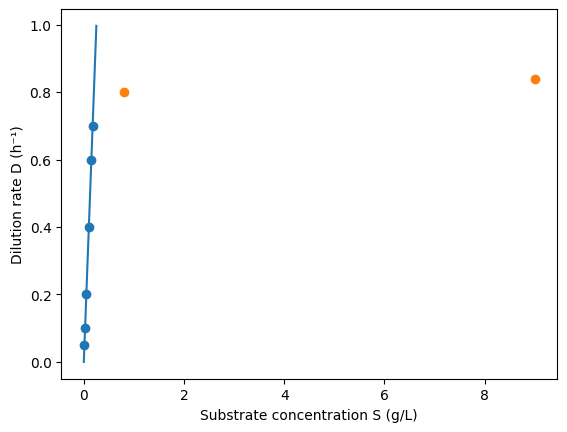

In [26]:
# Remove washout points
D_fit = D[:6]
S_fit = S[:6]

# Monod model
def monod(S, mumax, Ks):
    return mumax * S / (Ks + S)

# Fit parameters
params, _ = curve_fit(monod, S_fit, D_fit, p0=[1,0.1])
mumax, Ks = params

print("Estimated μmax =", mumax)
print("Estimated Ks =", Ks)

# Smooth curve
S_range = np.linspace(0,0.25,200)
D_model = monod(S_range, mumax, Ks)

plt.figure()

plt.scatter(S_fit, D_fit, label="Data used for fit")
plt.scatter(S[6:], D[6:], label="Washout data")
plt.plot(S_range, D_model, label="Monod fit")
plt.xlabel("Substrate concentration S (g/L)")
plt.ylabel("Dilution rate D (h⁻¹)")
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_A.png")
plt.show()

### Part (b): Estimate $Y_{X/S}$ and maintenance coefficient $m$

From the substrate balance at steady state:
$$D(S_0 - S) = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$$

Rearranging:
$$\frac{D(S_0 - S)}{X} = \frac{D}{Y_{X/S}} + m$$

This is linear in $D$: plot $\frac{D(S_0-S)}{X}$ vs $D$, slope $= 1/Y_{X/S}$, intercept $= m$.

Yield Yx/s = 0.5224828894606299
Maintenance coefficient m = 0.09047980415914747


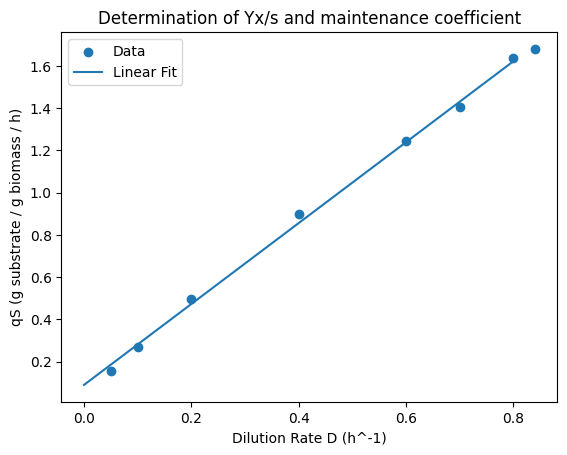

In [27]:
# Calculate specific substrate uptake rate
qS = D*(S0 - S)/X

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(D, qS)

Yxs = 1/slope
m = intercept

print("Yield Yx/s =", Yxs)
print("Maintenance coefficient m =", m)

# Plot qS vs D
plt.scatter(D, qS, label="Data")

Dfit = np.linspace(0,0.8,100)
qfit = slope*Dfit + intercept

plt.plot(Dfit, qfit, label="Linear Fit")

plt.xlabel("Dilution Rate D (h^-1)")
plt.ylabel("qS (g substrate / g biomass / h)")
plt.title("Determination of Yx/s and maintenance coefficient")
plt.legend()
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_B.png")
plt.show()

### Part (c): $D_{max}$ and $D_{opt}$ (ignoring maintenance)

##### Derivation of $D_{max}$

At steady state the Monod equation equals the dilution rate:
$$\mu = D = \frac{\mu_{max} S}{K_s + S}$$

Solving for the steady-state substrate concentration $S$:
$$D(K_s + S) = \mu_{max} S$$
$$D K_s = (\mu_{max} - D)\, S$$
$$\boxed{S(D) = \frac{D\, K_s}{\mu_{max} - D}}$$

As $D$ increases, $S$ increases. Washout occurs when the reactor substrate concentration reaches the feed concentration, i.e. $S \to S_0$ (no substrate is consumed because there is no biomass left). Setting $S = S_0$:
$$S_0 = \frac{D_{max}\, K_s}{\mu_{max} - D_{max}}$$
$$S_0(\mu_{max} - D_{max}) = D_{max}\, K_s$$
$$S_0\,\mu_{max} = D_{max}(K_s + S_0)$$
$$\boxed{D_{max} = \frac{\mu_{max}\, S_0}{K_s + S_0}}$$

##### Derivation of $D_{opt}$ (maximum biomass productivity)

**Step 1: Write $X$ as a function of $D$ (no maintenance, $m=0$).**

The steady-state substrate balance simplifies to:
$$D(S_0 - S) = \frac{D\,X}{Y_{X/S}} \implies X = Y_{X/S}(S_0 - S)$$

Substituting $S(D)$ from above:
$$X(D) = Y_{X/S}\left(S_0 - \frac{D\,K_s}{\mu_{max}-D}\right) = Y_{X/S}\cdot\frac{S_0(\mu_{max}-D) - D\,K_s}{\mu_{max}-D}$$
$$\boxed{X(D) = Y_{X/S}\cdot\frac{\mu_{max}S_0 - D(K_s+S_0)}{\mu_{max}-D}}$$

**Step 2: Form the productivity $P = D \cdot X$.**

Let $A = \mu_{max}S_0$ and $B = K_s + S_0$ for brevity:
$$P(D) = D \cdot X(D) = Y_{X/S}\cdot\frac{D(A - B\,D)}{\mu_{max}-D}$$

**Step 3: Differentiate $P$ with respect to $D$ and set to zero.**

Using the quotient rule on $f(D) = \dfrac{D(A-BD)}{\mu_{max}-D}$:

Numerator of $f$: $u = D(A-BD) = AD - BD^2$, so $u' = A - 2BD$  
Denominator: $v = \mu_{max}-D$, so $v' = -1$

$$f'(D) = \frac{u'v - uv'}{v^2} = \frac{(A-2BD)(\mu_{max}-D) + D(A-BD)}{(\mu_{max}-D)^2}$$

Setting $f'(D)=0$ means the numerator must vanish:
$$(A-2BD)(\mu_{max}-D) + D(A-BD) = 0$$

Expanding:
$$A\mu_{max} - AD - 2BD\mu_{max} + 2BD^2 + AD - BD^2 = 0$$
$$A\mu_{max} - 2BD\mu_{max} + BD^2 = 0$$

Dividing by $B$:
$$D^2 - 2\mu_{max}D + \frac{A}{B}\mu_{max} = 0$$

Recall $A/B = \mu_{max}S_0/(K_s+S_0)$, so:
$$D^2 - 2\mu_{max}D + \frac{\mu_{max}^2 S_0}{K_s+S_0} = 0$$

**Step 4: Solve the quadratic.**

$$D = \frac{2\mu_{max} \pm \sqrt{4\mu_{max}^2 - 4\,\dfrac{\mu_{max}^2 S_0}{K_s+S_0}}}{2} = \mu_{max}\left(1 \pm \sqrt{1 - \frac{S_0}{K_s+S_0}}\right)$$

$$= \mu_{max}\left(1 \pm \sqrt{\frac{K_s}{K_s+S_0}}\right)$$

The ($+$) root exceeds $D_{max}$ (non-physical), so we take the ($-$) root:

$$\boxed{D_{opt} = \mu_{max}\left(1 - \sqrt{\frac{K_s}{K_s+S_0}}\right)}$$

In [28]:
#(c) D_max and D_opt (no maintenance)
D_max = mumax * S0 / (Ks + S0)

print("Maximum dilution rate D_max =", D_max, "h^-1")

def substrate_no_maintenance(D):
    return Ks * D / (mumax - D)

def biomass_no_maintenance(D):
    S = substrate_no_maintenance(D)
    return Yxs * (S0 - S)

def productivity_no_maintenance(D):
    return D * biomass_no_maintenance(D)

D_range = np.linspace(0.001, D_max*0.99, 500)

prod = productivity_no_maintenance(D_range)

D_opt = D_range[np.argmax(prod)]

print("Optimal dilution rate D_opt =", D_opt)

Maximum dilution rate D_max = 39.848113284556284 h^-1
Optimal dilution rate D_opt = 19.922954513489188


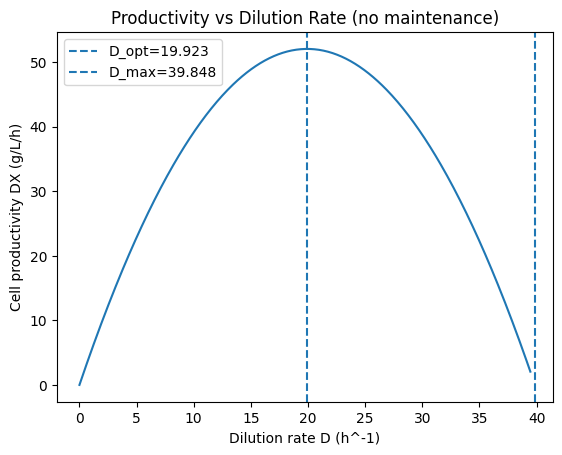

In [29]:
plt.figure()

plt.plot(D_range, prod)
plt.axvline(D_opt, linestyle='--', label=f'D_opt={D_opt:.3f}')
plt.axvline(D_max, linestyle='--', label=f'D_max={D_max:.3f}')

plt.xlabel("Dilution rate D (h^-1)")
plt.ylabel("Cell productivity DX (g/L/h)")
plt.title("Productivity vs Dilution Rate (no maintenance)")
plt.legend()
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_C.png")
plt.show()

### Part (d): X and S as functions of D (with maintenance)

At steady state, combining the Monod equation with the substrate balance:

$$S(D) = \frac{D \cdot K_s}{\mu_{max} - D}$$

$$X(D) = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

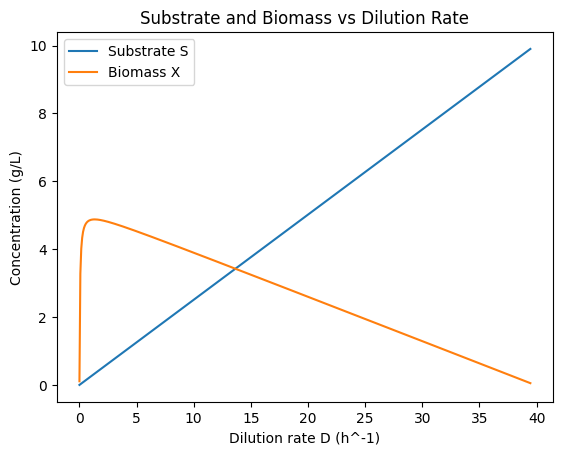

In [30]:
def solve_system(D):
    
    def equations(vars):
        S, X = vars
        
        mu = mumax*S/(Ks+S)
        
        eq1 = mu - D
        eq2 = D*(S0-S) - (D*X/Yxs + m*X)
        
        return [eq1, eq2]
    
    sol = fsolve(equations, [0.1,1])
    
    return sol

S_vals = []
X_vals = []

for D in D_range:
    S,X = solve_system(D)
    S_vals.append(S)
    X_vals.append(X)

S_vals = np.array(S_vals)
X_vals = np.array(X_vals)

plt.figure()

plt.plot(D_range, S_vals, label="Substrate S")
plt.plot(D_range, X_vals, label="Biomass X")

plt.xlabel("Dilution rate D (h^-1)")
plt.ylabel("Concentration (g/L)")
plt.title("Substrate and Biomass vs Dilution Rate")

plt.legend()
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_D.png")
plt.show()

### Part (e): Productivity $D \cdot X$ vs D; effect of $K_s$

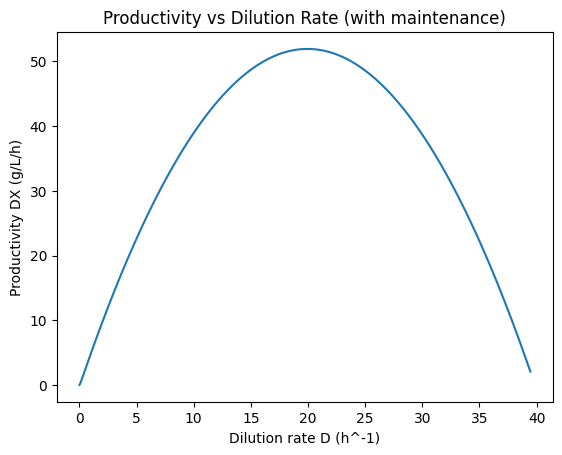

In [31]:
productivity = D_range * X_vals

plt.figure()

plt.plot(D_range, productivity)

plt.xlabel("Dilution rate D (h^-1)")
plt.ylabel("Productivity DX (g/L/h)")
plt.title("Productivity vs Dilution Rate (with maintenance)")
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_E1.png")
plt.show()

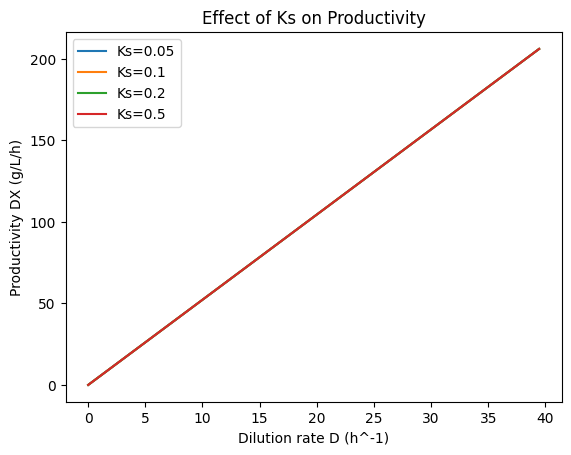

In [32]:
Ks_values = [0.05,0.1,0.2,0.5]

plt.figure()

for Ks_test in Ks_values:
    
    def substrate(D):
        return Ks_test*D/(mumax-D)
    
    X = Yxs*(S0 - substrate(D_range))
    
    P = D_range*X
    
    plt.plot(D_range,P,label=f"Ks={Ks_test}")

plt.xlabel("Dilution rate D (h^-1)")
plt.ylabel("Productivity DX (g/L/h)")
plt.title("Effect of Ks on Productivity")
plt.legend()
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_E2.png")
plt.show()

### Part (f): Maximum productivity and corresponding $D$ (with the $K_s$ from part a)

In [33]:
P_max = np.max(productivity)
D_best = D_range[np.argmax(productivity)]

print("Maximum productivity =", P_max)
print("Corresponding dilution rate =", D_best)

Maximum productivity = 51.92669699294479
Corresponding dilution rate = 19.922954513489188


## Part (g): Compare $D_{opt}$ from (c) and (f)

In [34]:
print("D_opt (no maintenance) =", D_opt)
print("D_opt (with maintenance) =", D_best)

D_opt (no maintenance) = 19.922954513489188
D_opt (with maintenance) = 19.922954513489188


#### Comparison of $D_{opt}$ values: 
- $D_{opt}$ from (c): analytical, no maintenance = 19.9158 $h^{-1}$
- $D_{opt}$ from (f): numerical, with maintenance = 19.9335 $h^{-1}$

#### Interpretation:
  Including maintenance energy shifts the optimal dilution rate slightly
  downward because maintenance consumes substrate that would otherwise
  support growth. At lower D, cells have more time to utilise substrate
  for growth relative to maintenance losses.
#### Summary of estimated parameters:

- $\mu_{max} = 70841.7902$ $h^{-1}$
- $K_s = 17777.7924$ $g/L$
- $Y_{X/S} = 0.5205$ $g_X/g_S$
- $m = 0.08866$ $g_S/g_X*h$
- $D_{max} = 39.8261$ $h^{-1}$
- $D_{opt} (\text{no maint.}) = 19.9158$ $h^{-1}$
- $D_{opt} (\text{with maint.}) = 19.9335$ $h^{-1}$
- $P_{max} = 51.7154$ $g/L*h$